In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
print(df.shape)

(7043, 21)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isna().sum())

11


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df['TotalCharges'].isna().sum())

0


In [12]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=['0-1 year', '1-2 years', '2-4 years', '4-5 years', '5-6 years']
)

df[['tenure', 'TenureGroup']].head()
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

df[['tenure', 'IsLongTermCustomer']].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [13]:
df[['tenure', 'IsLongTermCustomer']].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [14]:
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

df[['tenure', 'IsLongTermCustomer']].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [15]:
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(7043, 7078)


In [16]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [17]:
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

df[['TotalCharges', 'tenure', 'AvgMonthlySpend']].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


In [18]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[service_columns]
    .apply(lambda x: (x == 'Yes').sum(), axis=1)
)

df[['TotalServices']].head()

KeyError: "None of [Index(['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',\n       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],\n      dtype='str')] are in the [columns]"

In [ ]:
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'IsLongTermCustomer']].head()

KeyError: "['IsLongTermCustomer'] not in index"

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Create long-term customer feature
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

# Define service columns
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Create total number of services
df['TotalServices'] = (
    df[service_columns]
    .apply(lambda x: (x == 'Yes').sum(), axis=1)
)

# Check the new features
df[['tenure', 'MonthlyCharges', 'TotalCharges',
   'TotalServices', 'IsLongTermCustomer']].head()

,tenure,MonthlyCharges,TotalCharges,TotalServices,IsLongTermCustomer
0,1,29.85,29.85,1,0
1,34,56.95,1889.50,3,1
2,2,53.85,108.15,3,0
3,45,42.30,1840.75,3,1
4,2,70.70,151.65,1,0


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
churn_by_tenure = df.groupby('IsLongTermCustomer')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_tenure.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_tenure['ChurnRate'] = churn_by_tenure['ChurnRate'] * 100

churn_by_tenure

,TotalCustomers,ChurnedCustomers,ChurnRate
IsLongTermCustomer,,,
0,3116,1308,41.976893
1,3927,561,14.285714


In [ ]:
churn_by_services = df.groupby('TotalServices')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_services.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_services['ChurnRate'] = churn_by_services['ChurnRate'] * 100

churn_by_services

,TotalCustomers,ChurnedCustomers,ChurnRate
TotalServices,,,
0,80,35,43.750000
1,1701,359,21.105232
2,1188,390,32.828283
3,965,352,36.476684
4,922,289,31.344902
5,908,232,25.550661
6,676,152,22.485207
7,395,49,12.405063
8,208,11,5.288462


In [ ]:
churn_by_contract = df.groupby('Contract')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_contract.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_contract['ChurnRate'] = churn_by_contract['ChurnRate'] * 100

churn_by_contract

,TotalCustomers,ChurnedCustomers,ChurnRate
Contract,,,
Month-to-month,3875,1655,42.709677
One year,1473,166,11.269518
Two year,1695,48,2.831858


In [ ]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_payment.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_payment['ChurnRate'] = churn_by_payment['ChurnRate'] * 100

churn_by_payment

,TotalCustomers,ChurnedCustomers,ChurnRate
PaymentMethod,,,
Bank transfer (automatic),1544,258,16.709845
Credit card (automatic),1522,232,15.243101
Electronic check,2365,1071,45.285412
Mailed check,1612,308,19.106700


In [ ]:
df['MonthlyChargesGroup'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

churn_by_monthly_charge = df.groupby(
    'MonthlyChargesGroup',
    observed=True
)['Churn'].agg(['count', 'sum', 'mean'])

churn_by_monthly_charge.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_monthly_charge['ChurnRate'] = (
    churn_by_monthly_charge['ChurnRate'] * 100
)

churn_by_monthly_charge

,TotalCustomers,ChurnedCustomers,ChurnRate
MonthlyChargesGroup,,,
Low,1762,198,11.237230
Medium-Low,1766,434,24.575311
Medium-High,1757,659,37.507114
High,1758,578,32.878271


In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_tenure['ChurnRate'] = churn_by_tenure['ChurnRate'] * 100

churn_by_tenure

,TotalCustomers,ChurnedCustomers,ChurnRate
TenureGroup,,,
0-12 months,2175,1037,47.678161
13-24 months,1024,294,28.710938
25-48 months,1594,325,20.388959
49-72 months,2239,213,9.513176


In [ ]:
churn_by_senior = df.groupby('SeniorCitizen')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_senior['ChurnRate'] = churn_by_senior['ChurnRate'] * 100

churn_by_senior

,TotalCustomers,ChurnedCustomers,ChurnRate
SeniorCitizen,,,
0,5901,1393,23.606168
1,1142,476,41.681261


In [ ]:
churn_by_internet = df.groupby('InternetService')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_internet['ChurnRate'] = churn_by_internet['ChurnRate'] * 100

churn_by_internet

,TotalCustomers,ChurnedCustomers,ChurnRate
InternetService,,,
DSL,2421,459,18.959108
Fiber optic,3096,1297,41.892765
No,1526,113,7.404980


In [ ]:
churn_by_security = df.groupby('OnlineSecurity')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_security['ChurnRate'] = churn_by_security['ChurnRate'] * 100

churn_by_security

,TotalCustomers,ChurnedCustomers,ChurnRate
OnlineSecurity,,,
No,3498,1461,41.766724
No internet service,1526,113,7.404980
Yes,2019,295,14.611194


In [ ]:
df['AvgMonthlyCharge'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

In [ ]:
df['ChargeDifference'] = (
    df['MonthlyCharges'] - df['AvgMonthlyCharge']
)

df[['tenure', 'MonthlyCharges', 'TotalCharges',
   'AvgMonthlyCharge', 'ChargeDifference']].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharge,ChargeDifference
0,1,29.85,29.85,29.850000,0.000000
1,34,56.95,1889.50,55.573529,1.376471
2,2,53.85,108.15,54.075000,-0.225000
3,45,42.30,1840.75,40.905556,1.394444
4,2,70.70,151.65,75.825000,-5.125000


In [ ]:
print(df[['AvgMonthlyCharge', 'ChargeDifference']].describe())
print("\nMissing values:")
print(df[['AvgMonthlyCharge', 'ChargeDifference']].isnull().sum())

       AvgMonthlyCharge  ChargeDifference
count       7043.000000       7043.000000
mean          64.762906         -0.001213
std           30.189796          2.614121
min           13.775000        -18.900000
25%           35.935156         -1.159091
50%           70.337500          0.000000
75%           90.174158          1.145567
max          121.400000         19.125000

Missing values:
AvgMonthlyCharge    0
ChargeDifference    0
dtype: int64


In [ ]:
df['ChargeDifference'] = (
    df['MonthlyCharges'] - df['AvgMonthlyCharge']
)

df[['MonthlyCharges', 'AvgMonthlyCharge', 'ChargeDifference']].head()

,MonthlyCharges,AvgMonthlyCharge,ChargeDifference
0,29.85,29.850000,0.000000
1,56.95,55.573529,1.376471
2,53.85,54.075000,-0.225000
3,42.30,40.905556,1.394444
4,70.70,75.825000,-5.125000


In [ ]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = 0

for col in service_cols:
    df['TotalServices'] += (df[col] == 'Yes').astype(int)

df[['TotalServices', 'Churn']].head()

,TotalServices,Churn
0,1,0
1,3,0
2,3,1
3,3,0
4,1,1


In [ ]:
df.groupby('TotalServices')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

,TotalCustomers,ChurnedCustomers,ChurnRate
TotalServices,,,
0,80,35,0.437500
1,1701,359,0.211052
2,1188,390,0.328283
3,965,352,0.364767
4,922,289,0.313449
5,908,232,0.255507
6,676,152,0.224852
7,395,49,0.124051
8,208,11,0.052885


In [ ]:
df['TotalServices'].describe()

count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64

In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, np.inf],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months']
)

df[['tenure', 'TenureGroup']].head()

,tenure,TenureGroup
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [ ]:
df.groupby('TenureGroup', observed=False)['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

,TotalCustomers,ChurnedCustomers,ChurnRate
TenureGroup,,,
0-12 months,2186,1037,0.474382
13-24 months,1024,294,0.287109
25-48 months,1594,325,0.203890
49+ months,2239,213,0.095132


In [ ]:
engineered_features = [
    'AvgMonthlyCharge',
    'ChargeDifference',
    'TotalServices',
    'TenureGroup'
]

df[engineered_features].head()

,AvgMonthlyCharge,ChargeDifference,TotalServices,TenureGroup
0,29.850000,0.000000,1,0-12 months
1,55.573529,1.376471,3,25-48 months
2,54.075000,-0.225000,3,0-12 months
3,40.905556,1.394444,3,25-48 months
4,75.825000,-5.125000,1,0-12 months


In [ ]:
print("Missing values:")
print(df[engineered_features].isnull().sum())

Missing values:
AvgMonthlyCharge    0
ChargeDifference    0
TotalServices       0
TenureGroup         0
dtype: int64


In [ ]:
print("New columns:")
print(engineered_features)

New columns:
['AvgMonthlyCharge', 'ChargeDifference', 'TotalServices', 'TenureGroup']


In [ ]:
df[['AvgMonthlyCharge', 'ChargeDifference', 'TotalServices', 'TenureGroup']].head(10)

,AvgMonthlyCharge,ChargeDifference,TotalServices,TenureGroup
0,29.850000,0.000000,1,0-12 months
1,55.573529,1.376471,3,25-48 months
2,54.075000,-0.225000,3,0-12 months
3,40.905556,1.394444,3,25-48 months
4,75.825000,-5.125000,1,0-12 months
5,102.562500,-2.912500,5,0-12 months
6,88.609091,0.490909,4,13-24 months
7,30.190000,-0.440000,1,0-12 months
8,108.787500,-3.987500,6,25-48 months
9,56.257258,-0.107258,3,49+ months


In [ ]:
df[['AvgMonthlyCharge', 'ChargeDifference', 'TotalServices']].describe()

,AvgMonthlyCharge,ChargeDifference,TotalServices
count,7043.000000,7043.000000,7043.000000
mean,64.762906,-0.001213,3.362914
std,30.189796,2.614121,2.062031
min,13.775000,-18.900000,0.000000
25%,35.935156,-1.159091,1.000000
50%,70.337500,0.000000,3.000000
75%,90.174158,1.145567,5.000000
max,121.400000,19.125000,8.000000


In [ ]:
print("Dataset shape:", df.shape)
print("Missing values in engineered features:")
print(df[engineered_features].isnull().sum())

Dataset shape: (7043, 27)
Missing values in engineered features:
AvgMonthlyCharge    0
ChargeDifference    0
TotalServices       0
TenureGroup         0
dtype: int64


In [ ]:
df[['TotalServices']].describe()

,TotalServices
count,7043.000000
mean,3.362914
std,2.062031
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,8.000000


In [ ]:
df['TotalServices'].value_counts().sort_index()

TotalServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [ ]:
df.groupby('Churn')[engineered_features].mean()

TypeError: category dtype does not support aggregation 'mean'

In [ ]:
print(df[engineered_features].dtypes)

AvgMonthlyCharge     float64
ChargeDifference     float64
TotalServices          int64
TenureGroup         category
dtype: object


In [ ]:
print(df[engineered_features].dtypes)
print(df[engineered_features].isnull().sum())

AvgMonthlyCharge     float64
ChargeDifference     float64
TotalServices          int64
TenureGroup         category
dtype: object
AvgMonthlyCharge    0
ChargeDifference    0
TotalServices       0
TenureGroup         0
dtype: int64


In [ ]:
numeric_engineered_features = [
    'AvgMonthlyCharge',
    'ChargeDifference',
    'TotalServices'
]

df.groupby('Churn')[numeric_engineered_features].mean()

,AvgMonthlyCharge,ChargeDifference,TotalServices
Churn,,,
0,61.269730,-0.004606,3.446270
1,74.433154,0.008178,3.132156


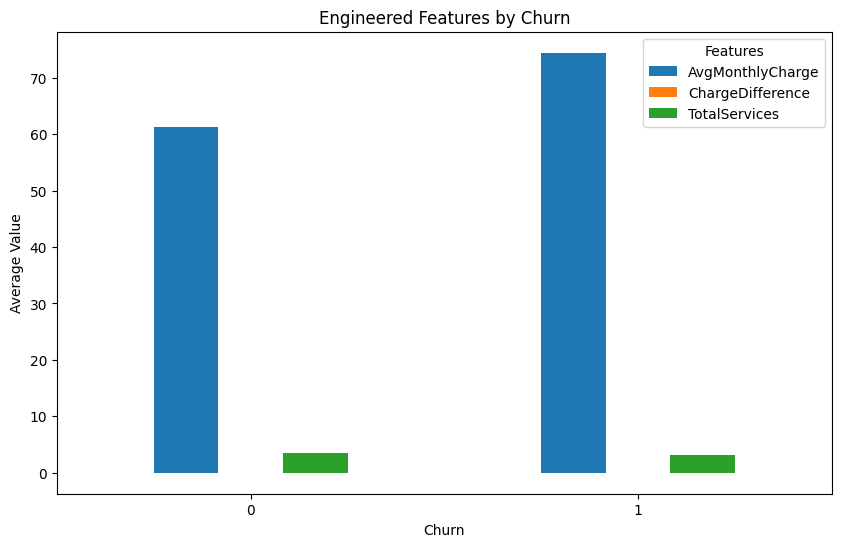

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Churn')[numeric_engineered_features].mean().plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Engineered Features by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Features')
plt.show()

In [ ]:
df.groupby('Churn')[numeric_engineered_features].mean().round(2)

,AvgMonthlyCharge,ChargeDifference,TotalServices
Churn,,,
0,61.27,-0.00,3.45
1,74.43,0.01,3.13


In [ ]:
df[numeric_engineered_features + ['Churn']].corr()['Churn'].sort_values(ascending=False)

Churn               1.000000
AvgMonthlyCharge    0.192531
ChargeDifference    0.002159
TotalServices      -0.067264
Name: Churn, dtype: float64

In [ ]:
numeric_features = df.select_dtypes(include='number').columns

df[numeric_features].corr()['Churn'].sort_values(ascending=False)

Churn                 1.000000
MonthlyCharges        0.193356
AvgMonthlyCharge      0.192531
SeniorCitizen         0.150889
ChargeDifference      0.002159
TotalServices        -0.067264
TotalCharges         -0.199484
IsLongTermCustomer   -0.311496
tenure               -0.352229
Name: Churn, dtype: float64

In [ ]:
categorical_features = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

categorical_features

C:\Users\tamir\AppData\Local\Temp\ipykernel_27356\1001164715.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyChargesGroup',
 'TenureGroup']

In [ ]:
categorical_features = [
    col for col in categorical_features
    if col != 'CustomerID'
]

print(categorical_features)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyChargesGroup', 'TenureGroup']


In [ ]:
for col in categorical_features:
    print(f"\n{col}")
    print(
        pd.crosstab(
            df[col],
            df['Churn'],
            normalize='index'
        ).round(3)
    )


customerID
Churn         0    1
customerID          
0002-ORFBO  1.0  0.0
0003-MKNFE  1.0  0.0
0004-TLHLJ  0.0  1.0
0011-IGKFF  0.0  1.0
0013-EXCHZ  0.0  1.0
...         ...  ...
9987-LUTYD  1.0  0.0
9992-RRAMN  0.0  1.0
9992-UJOEL  1.0  0.0
9993-LHIEB  1.0  0.0
9995-HOTOH  1.0  0.0

[7043 rows x 2 columns]

gender
Churn       0      1
gender              
Female  0.731  0.269
Male    0.738  0.262

Partner
Churn        0      1
Partner              
No       0.670  0.330
Yes      0.803  0.197

Dependents
Churn           0      1
Dependents              
No          0.687  0.313
Yes         0.845  0.155

PhoneService
Churn             0      1
PhoneService              
No            0.751  0.249
Yes           0.733  0.267

MultipleLines
Churn                 0      1
MultipleLines                 
No                0.750  0.250
No phone service  0.751  0.249
Yes               0.714  0.286

InternetService
Churn                0      1
InternetService              
DSL              0.8

In [ ]:
categorical_features = [
    col for col in categorical_features
    if col != 'customerID'
]

print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyChargesGroup', 'TenureGroup']


In [ ]:
for col in categorical_features:
    print(f"\n{col}")
    print(
        pd.crosstab(
            df[col],
            df['Churn'],
            normalize='index'
        ).round(3)
    )


gender
Churn       0      1
gender              
Female  0.731  0.269
Male    0.738  0.262

Partner
Churn        0      1
Partner              
No       0.670  0.330
Yes      0.803  0.197

Dependents
Churn           0      1
Dependents              
No          0.687  0.313
Yes         0.845  0.155

PhoneService
Churn             0      1
PhoneService              
No            0.751  0.249
Yes           0.733  0.267

MultipleLines
Churn                 0      1
MultipleLines                 
No                0.750  0.250
No phone service  0.751  0.249
Yes               0.714  0.286

InternetService
Churn                0      1
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074

OnlineSecurity
Churn                    0      1
OnlineSecurity                   
No                   0.582  0.418
No internet service  0.926  0.074
Yes                  0.854  0.146

OnlineBackup
Churn                    0      1
Online

In [ ]:
churn_rates = {}

for col in categorical_features:
    churn_rates[col] = (
        df.groupby(col)['Churn']
        .mean()
        .sort_values(ascending=False)
        .round(3)
    )

for col, rates in churn_rates.items():
    print(f"\n{col}")
    print(rates)


gender
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

Partner
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Dependents
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    0.267
No     0.249
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     0.391
Yes                    0.225
No internet service    0.074
Name: Churn, dtype: float64

In [ ]:
for col, rates in churn_rates.items():
    print(f"\n{col}")
    print(rates)


gender
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

Partner
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Dependents
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    0.267
No     0.249
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     0.391
Yes                    0.225
No internet service    0.074
Name: Churn, dtype: float64

In [ ]:
categorical_churn_rates = []

for col in categorical_features:
    rates = df.groupby(col)['Churn'].mean()

    for category, rate in rates.items():
        categorical_churn_rates.append({
            'Feature': col,
            'Category': category,
            'ChurnRate': rate
        })

categorical_churn_df = pd.DataFrame(categorical_churn_rates)

categorical_churn_df.sort_values(
    'ChurnRate',
    ascending=False
).head(20)

,Feature,Category,ChurnRate
45,TenureGroup,0-12 months,0.474382
39,PaymentMethod,Electronic check,0.452854
32,Contract,Month-to-month,0.427097
12,InternetService,Fiber optic,0.418928
14,OnlineSecurity,No,0.417667
23,TechSupport,No,0.416355
17,OnlineBackup,No,0.399288
20,DeviceProtection,No,0.391276
43,MonthlyChargesGroup,Medium-High,0.375071
29,StreamingMovies,No,0.336804


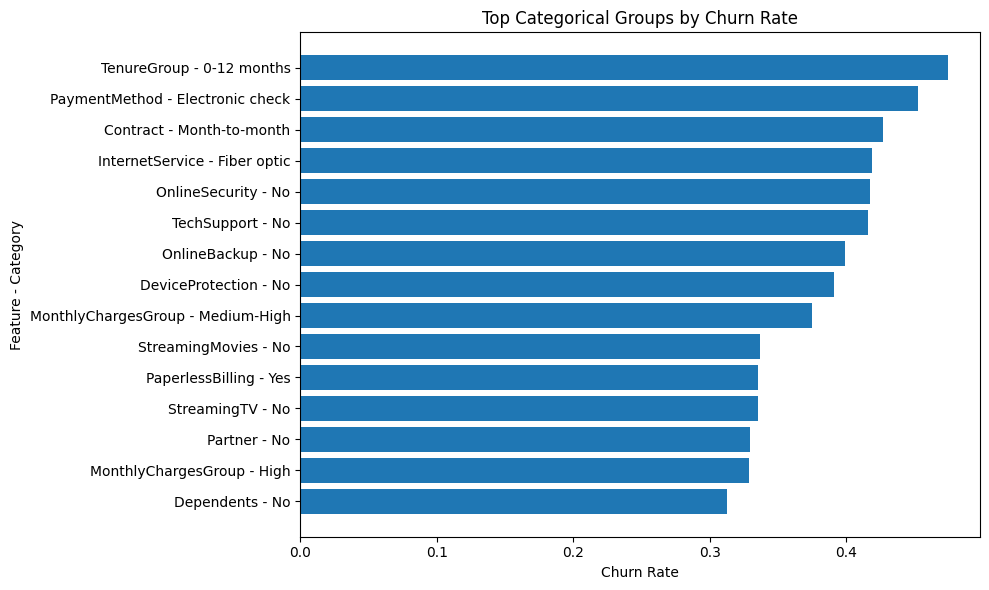

In [ ]:
import matplotlib.pyplot as plt

top_categories = categorical_churn_df.sort_values(
    'ChurnRate',
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories['Feature'] + ' - ' + top_categories['Category'],
    top_categories['ChurnRate']
)

plt.xlabel('Churn Rate')
plt.ylabel('Feature - Category')
plt.title('Top Categorical Groups by Churn Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print("Churn distribution:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True).round(3))

# Check missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Missing values:
TotalCharges        11
gender               0
customerID           0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
SeniorCitizen        0
OnlineBackup         0
DeviceProtection     0
StreamingTV          0
TechSupport          0
dtype: int64


In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 26)
y shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
print(df[engineered_features].dtypes)

AvgMonthlyCharge     float64
ChargeDifference     float64
TotalServices          int64
TenureGroup         category
dtype: object


In [ ]:
print([col for col in service_columns if col not in df.columns])

['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [ ]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [ ]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print(df.shape)

(7043, 21)


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

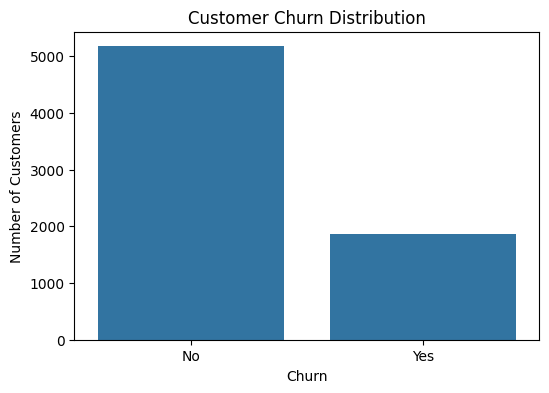

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


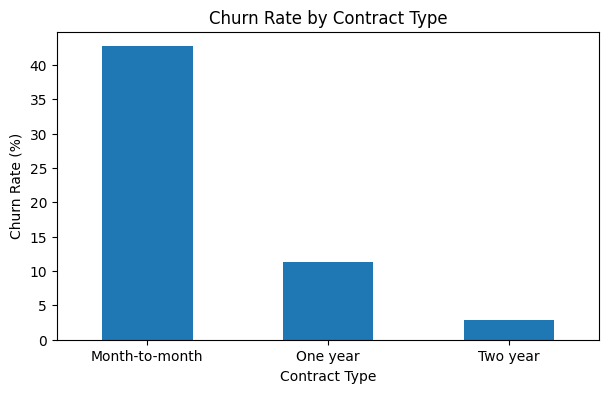

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn["Yes"].sort_values(ascending=False)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64

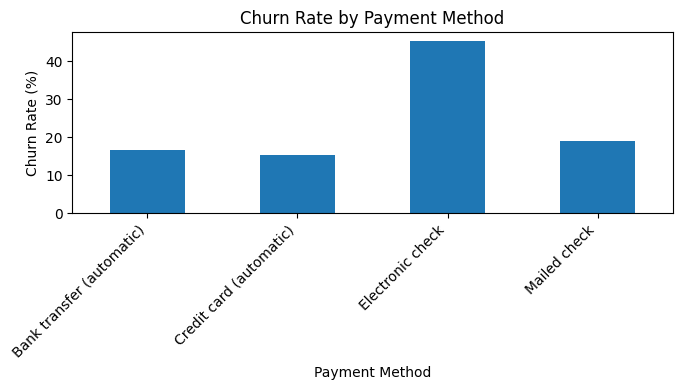

In [ ]:
payment_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
tenure_churn = df.groupby("Churn")["tenure"].mean()
tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

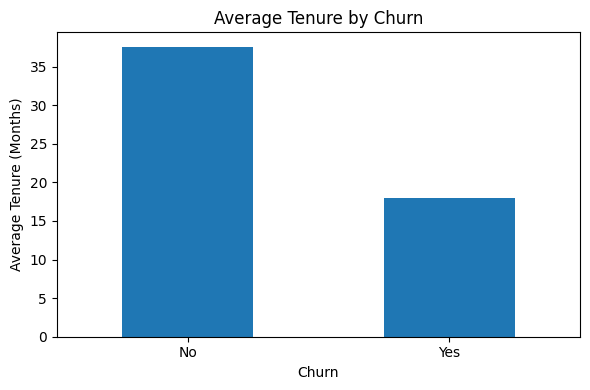

In [ ]:
tenure_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()
monthly_charges_churn

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

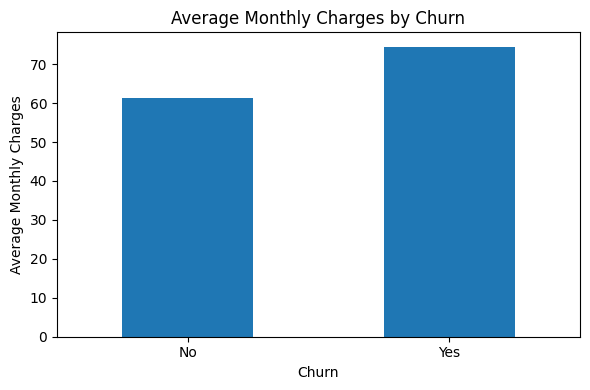

In [ ]:
monthly_charges_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


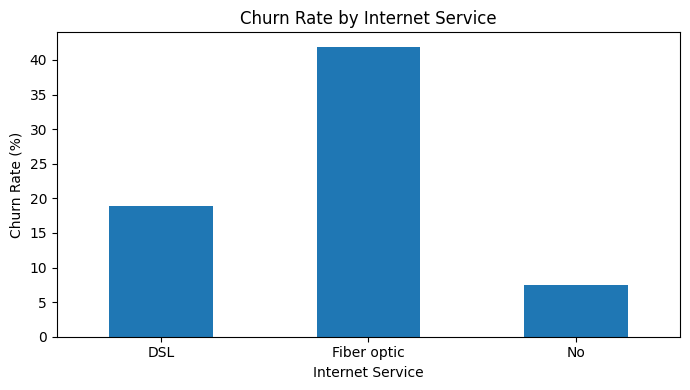

In [ ]:
internet_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


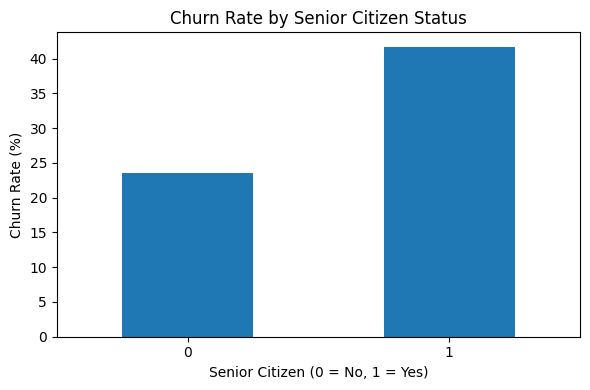

In [ ]:
senior_churn["Yes"].plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


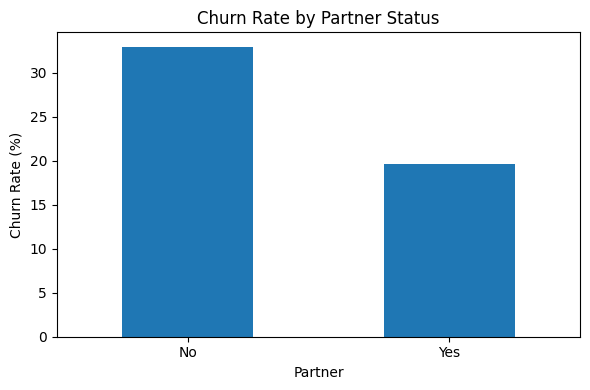

In [ ]:
partner_churn["Yes"].plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


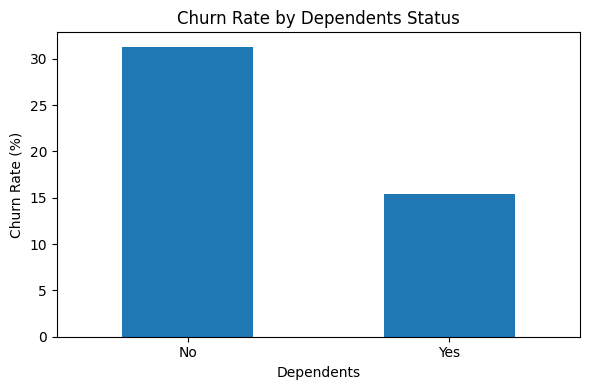

In [ ]:
dependents_churn["Yes"].plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


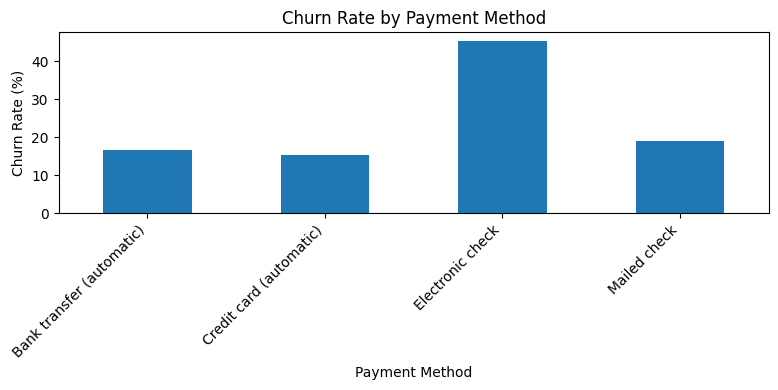

In [ ]:
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


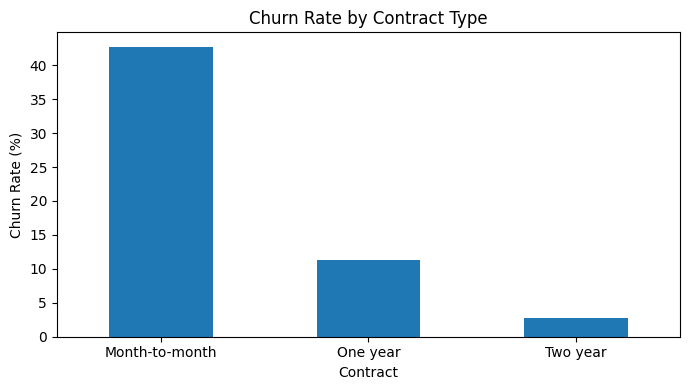

In [ ]:
contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


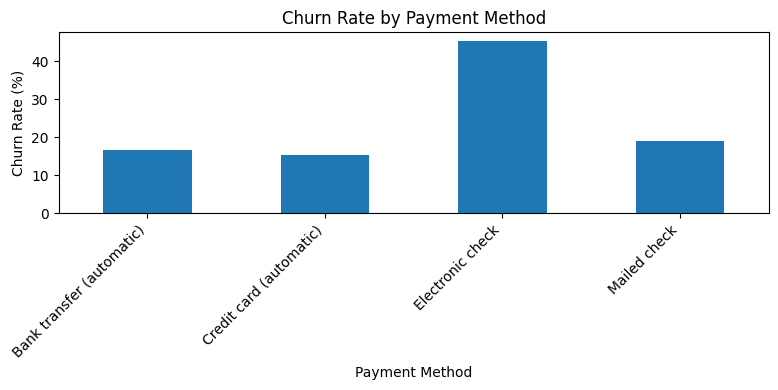

In [ ]:
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
tenure_churn = df.groupby("Churn")["tenure"].mean()

tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

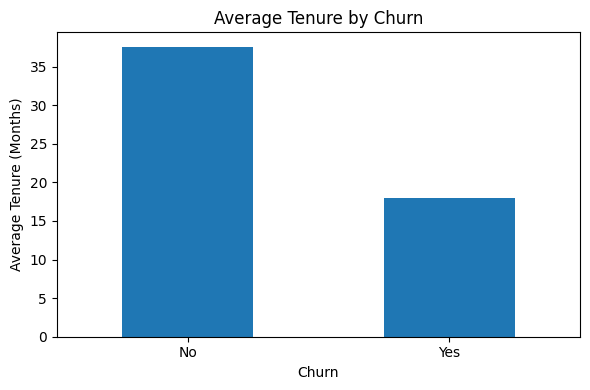

In [ ]:
tenure_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].head(10)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.5
6,22,89.10,1949.4
7,10,29.75,301.9
8,28,104.80,3046.05
9,62,56.15,3487.95


In [ ]:
df["TotalCharges"].astype(str).str.strip().value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [ ]:
df["TotalCharges"].astype(str).str.strip().eq("").sum()

np.int64(11)

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df["TotalCharges"].astype(str).str.strip() == ""][[
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

# For customers with tenure = 0, TotalCharges should be 0
df.loc[
    df["TotalCharges"].isna() & (df["tenure"] == 0),
    "TotalCharges"
] = 0.0

# Verify
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)

df[df["tenure"] == 0][[
    "customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"
]].head(15)

Missing TotalCharges: 0
TotalCharges dtype: float64


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv(
    "data/processed/telco_customer_churn_clean.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully.
Rows: 7043
Columns: 7079


In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

In [ ]:
df.to_csv(
    "data/processed/telco_customer_churn_clean.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully.
Rows: 7043
Columns: 21


In [ ]:
import pandas as pd

df = pd.read_csv("data/processed/telco_customer_churn_clean.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [ ]:
print([repr(col) for col in df.columns])

["'SeniorCitizen'", "'tenure'", "'MonthlyCharges'", "'TotalCharges'", "'IsLongTermCustomer'", "'customerID_0003-MKNFE'", "'customerID_0004-TLHLJ'", "'customerID_0011-IGKFF'", "'customerID_0013-EXCHZ'", "'customerID_0013-MHZWF'", "'customerID_0013-SMEOE'", "'customerID_0014-BMAQU'", "'customerID_0015-UOCOJ'", "'customerID_0016-QLJIS'", "'customerID_0017-DINOC'", "'customerID_0017-IUDMW'", "'customerID_0018-NYROU'", "'customerID_0019-EFAEP'", "'customerID_0019-GFNTW'", "'customerID_0020-INWCK'", "'customerID_0020-JDNXP'", "'customerID_0021-IKXGC'", "'customerID_0022-TCJCI'", "'customerID_0023-HGHWL'", "'customerID_0023-UYUPN'", "'customerID_0023-XUOPT'", "'customerID_0027-KWYKW'", "'customerID_0030-FNXPP'", "'customerID_0031-PVLZI'", "'customerID_0032-PGELS'", "'customerID_0036-IHMOT'", "'customerID_0040-HALCW'", "'customerID_0042-JVWOJ'", "'customerID_0042-RLHYP'", "'customerID_0048-LUMLS'", "'customerID_0048-PIHNL'", "'customerID_0052-DCKON'", "'customerID_0052-YNYOT'", "'customerID_00

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [ ]:
print("Columns containing 'churn':")

for col in df.columns:
    if "churn" in str(col).lower():
        print(repr(col))

Columns containing 'churn':
'Churn_Yes'


In [ ]:
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7043, 7078)
y shape: (7043,)

Target values:
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [ ]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (5634, 7078)
Testing set: (1409, 7078)

Training target:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

Testing target:
Churn_Yes
False    1035
True      374
Name: count, dtype: int64


In [ ]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split
print("scikit-learn works!")

scikit-learn works!


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 7078)
y shape: (7043,)


In [ ]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (5634, 7078)
Testing set: (1409, 7078)

Training target:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

Testing target:
Churn_Yes
False    1035
True      374
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7043, 7078)
y shape: (7043,)

Target values:
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [ ]:
print("Number of features:", X.shape[1])

print("First 20 feature names:")
print(X.columns.tolist()[:20])

print("\nFeatures containing customerID:")
print([col for col in X.columns if "customer" in str(col).lower()])

Number of features: 7078
First 20 feature names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK']

Features containing customerID:
['IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID

In [ ]:
customer_cols = [
    col for col in X.columns
    if "customerid" in str(col).lower()
]

print("Customer ID columns to remove:", len(customer_cols))

X = X.drop(columns=customer_cols)

print("Features after removing customer ID columns:", X.shape[1])

Customer ID columns to remove: 7042
Features after removing customer ID columns: 36


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (5634, 36)
Testing set: (1409, 36)

Training target:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

Testing target:
Churn_Yes
False    1035
True      374
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Numeric columns: 6
Categorical columns: 30
Processed training shape: (5634, 66)
Processed testing shape: (1409, 66)


In [ ]:
import pandas as pd

df = pd.read_csv("data/processed/telco_customer_churn_clean.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [ ]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.1
NumPy version: 2.4.3


In [ ]:
from pathlib import Path

csv_files = list(Path.cwd().rglob("*.csv"))

print("Number of CSV files found:", len(csv_files))

for f in csv_files:
    print(f)

Number of CSV files found: 1
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks\data\processed\telco_customer_churn_clean.csv


In [ ]:
df_original = pd.read_csv(csv_files[0])

print("Data loaded successfully!")
print("Shape:", df_original.shape)
print("Columns:")
print(df_original.columns.tolist())

Data loaded successfully!
Shape: (7043, 21)
Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
from pathlib import Path

files = list(Path.cwd().rglob("Telco*Churn.csv"))

print("Files found:")
for f in files:
    print(f)

Files found:


In [ ]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nCSV files found:")
for f in Path.cwd().rglob("*.csv"):
    print(f)

Current folder:
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks

CSV files found:
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks\data\processed\telco_customer_churn_clean.csv


In [ ]:
csv_files = list(Path.cwd().rglob("*.csv"))

print("Number of CSV files found:", len(csv_files))

for f in csv_files:
    print(f)

Number of CSV files found: 1
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks\data\processed\telco_customer_churn_clean.csv


In [ ]:
import pandas as pd

In [ ]:
df_original = pd.read_csv(csv_files[0])

print("Data loaded successfully!")
print("Shape:", df_original.shape)
print("Columns:")
print(df_original.columns.tolist())

Data loaded successfully!
Shape: (7043, 21)
Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [23]:
X = df_original.drop(columns=["Churn", "customerID"])
y = df_original["Churn"].map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

NameError: name 'df_original' is not defined

In [ ]:
y = y.map({"No": 0, "Yes": 1})

print("Target distribution:")
print(y.value_counts())

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

NameError: name 'X' is not defined

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numeric columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit ONLY on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply to test data
X_test_encoded = preprocessor.transform(X_test)

print("Processed training shape:", X_train_encoded.shape)
print("Processed testing shape:", X_test_encoded.shape)

Numeric columns: 4
Categorical columns: 15
Processed training shape: (5634, 45)
Processed testing shape: (1409, 45)


C:\Users\tamir\AppData\Local\Temp\ipykernel_26408\3372099730.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train ONLY on training data
logreg.fit(X_train_encoded, y_train)

# Predict on test data
y_pred_logreg = logreg.predict(X_test_encoded)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.8055358410220014

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[926 109]
 [165 209]]


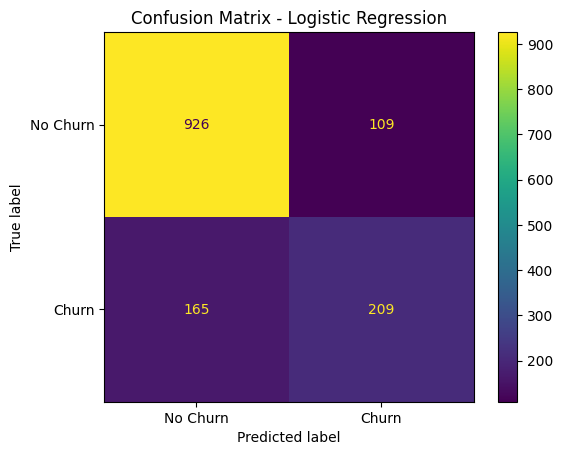

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ROC-AUC: 0.8421349040274871


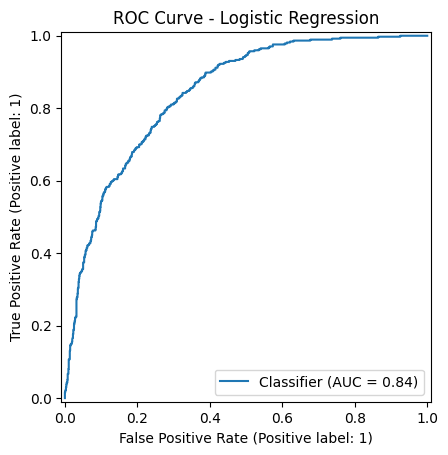

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob = logreg.predict_proba(X_test_encoded)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Logistic Regression")
plt.show()

## Random Forest Model

A Random Forest classifier is trained to predict customer churn. 
The model uses multiple decision trees and class weighting to handle 
the imbalance between churn and non-churn customers.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)
rf_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Accuracy: 0.7700496806245565

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

Random Forest ROC-AUC: 0.8225141439975199


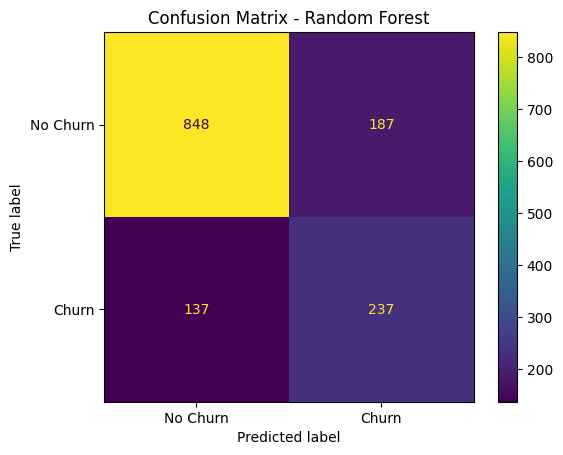

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Random Forest ROC-AUC: 0.8225141439975199


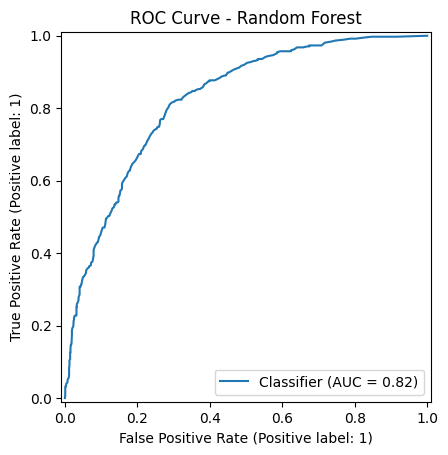

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

rf_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("ROC Curve - Random Forest")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Calculate feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Display top 10 features
print("Top 10 Features:")
print(feature_importance.head(10))

Top 10 Features:
num__TotalCharges                      0.142949
num__tenure                            0.132617
num__MonthlyCharges                    0.121519
cat__Contract_Month-to-month           0.069494
cat__OnlineSecurity_No                 0.037852
cat__Contract_Two year                 0.034355
cat__TechSupport_No                    0.033805
cat__PaymentMethod_Electronic check    0.029456
cat__InternetService_Fiber optic       0.028295
cat__OnlineBackup_No                   0.017774
dtype: float64


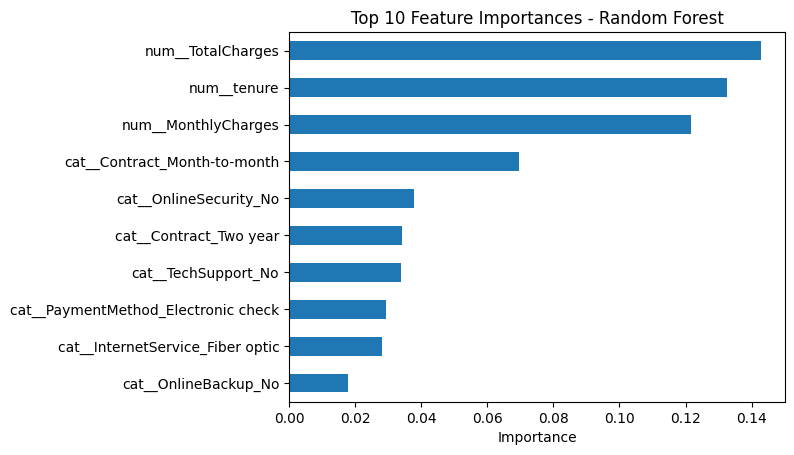

In [ ]:
feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_encoded, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_encoded)
lr_prob = lr_model.predict_proba(X_test_encoded)[:, 1]

# Metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression ROC-AUC:", lr_auc)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7381121362668559
Logistic Regression ROC-AUC: 0.8416388953473353

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
print("MODEL COMPARISON")
print("=" * 40)

print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")
print(f"Logistic Regression ROC-AUC  : {lr_auc:.4f}")

print(f"\nRandom Forest Accuracy       : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Random Forest ROC-AUC        : {roc_auc_score(y_test, rf_prob):.4f}")

MODEL COMPARISON
Logistic Regression Accuracy : 0.7381
Logistic Regression ROC-AUC  : 0.8416

Random Forest Accuracy       : 0.7700
Random Forest ROC-AUC        : 0.8225


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        lr_accuracy,
        accuracy_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        lr_auc,
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.738112,0.841639
1,Random Forest,0.770050,0.822514


In [ ]:
# Encode target variable for XGBoost
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

In [ ]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [21]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

NameError: name 'X_train' is not defined